# A. Load Dataset and EDA. #

In [1]:
import pandas as pd
insurance_dataset = pd.read_csv('insurance.csv')
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [5]:
print(f"Shape of data: {insurance_dataset.shape}")

Shape of data: (1338, 7)


- "age" column represents the age of the primary insured individual (in years).
- sex: The gender of the policyholder (female or male).
- bmi: Body Mass Index, providing an understanding of body weight relative to height (kg/m^2), where an ideal range is typically between 18.5 and 24.9.
- children: The number of children / dependents covered by the health insurance plan.
- smoker: Smoking status of the individual (yes if they smoke, no if they do not). This is typically one of the strongest predictors of medical costs.
- region: The beneficiary's residential area in the US, divided into four quadrants: northeast, southeast, southwest, and northwest.
- charges: Individual medical costs billed by health insurance / medical bills (this is the target variable you will use models to predict).

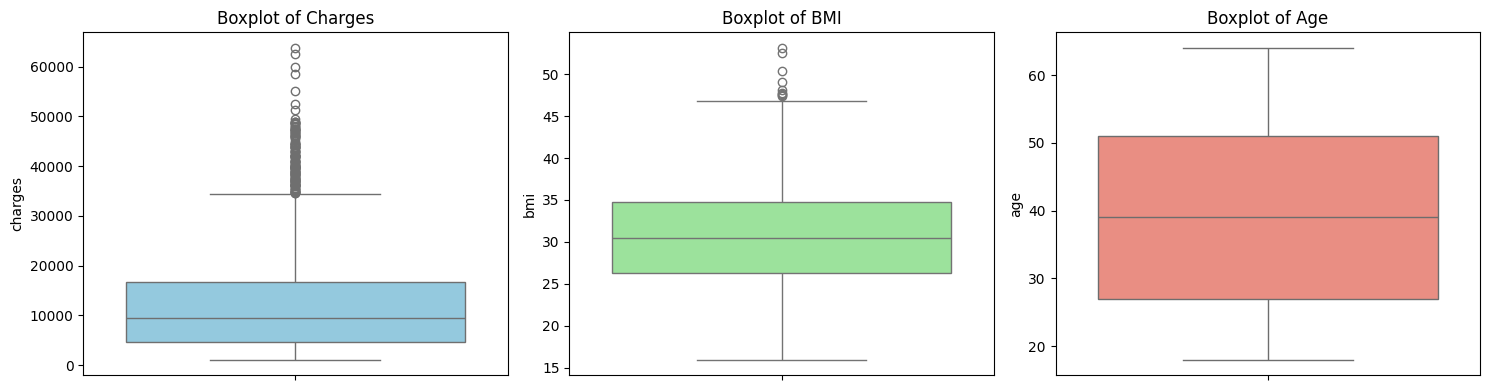

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=insurance_dataset['charges'], color='skyblue')
plt.title('Boxplot of Charges')

plt.subplot(1, 3, 2)
sns.boxplot(y=insurance_dataset['bmi'], color='lightgreen')
plt.title('Boxplot of BMI')

plt.subplot(1, 3, 3)
sns.boxplot(y=insurance_dataset['age'], color='salmon')
plt.title('Boxplot of Age')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3263/4013345604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=insurance_dataset, x=col, palette='Set2')
/tmp/ipykernel_3263/4013345604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=insurance_dataset, x=col, palette='Set2')
/tmp/ipykernel_3263/4013345604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=insurance_dataset, x=col, palette='Set2')


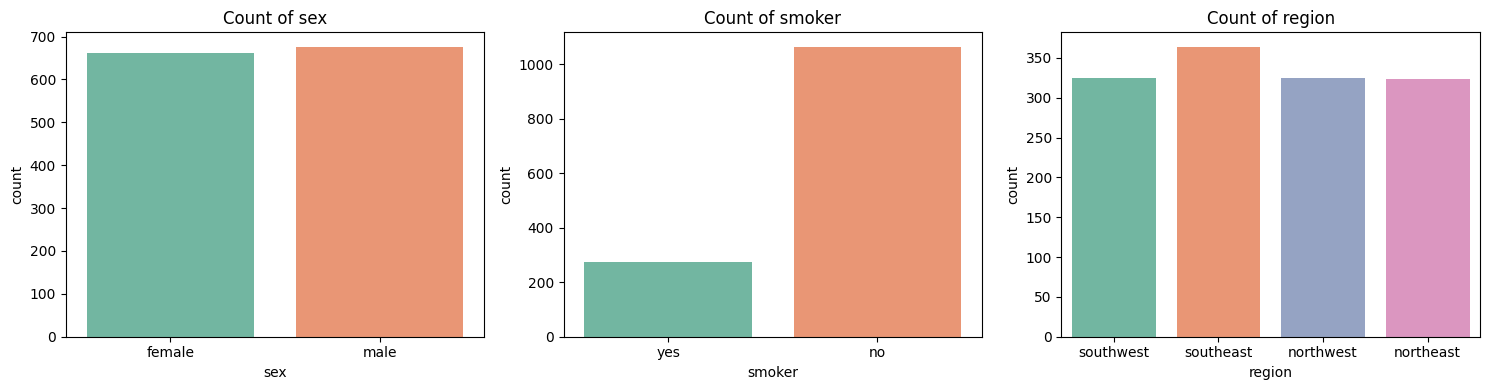

In [7]:
plt.figure(figsize=(15, 4))
cat_cols = ['sex', 'smoker', 'region']
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=insurance_dataset, x=col, palette='Set2')
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

--- Correlation Coefficients with charges ---
charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


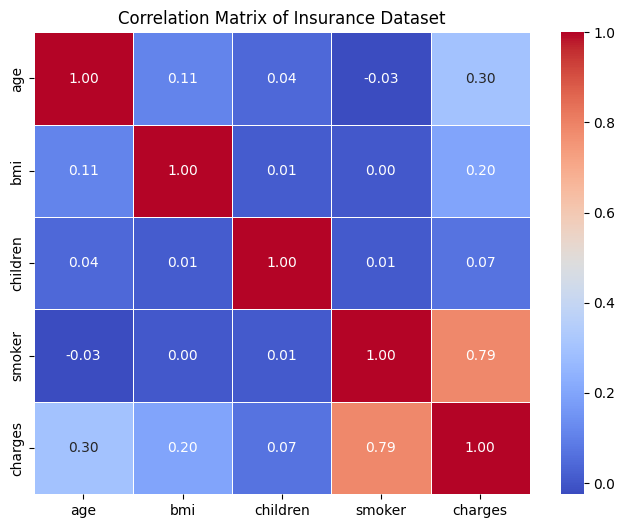

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#-- Categorical columns (sex, smoker, region) need to be encoded into numbers first. --#
#-- Create a temporary copy and map 'smoker' ('yes'=1, 'no'=0) for a quick numerical correlation check. --#
df_temp = insurance_dataset.copy()
df_temp['smoker'] = df_temp['smoker'].map({'yes': 1, 'no': 0})
#-- Compute correlation matrix for numeric columns. --#
numeric_cols = ['age', 'bmi', 'children', 'smoker', 'charges']
corr_matrix = df_temp[numeric_cols].corr()
#-- Print out correlation coefficients with 'charges'. --#
print("--- Correlation Coefficients with charges ---")
print(corr_matrix['charges'].sort_values(ascending=False))
#-- Plot the Heatmap. --#
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Insurance Dataset')
plt.show()

According to the Figure above, it is clear from the correlation matrix that smoker has the strongest positive correlation with charges ($0.79$), followed by age ($0.30$) and bmi ($0.20$).Smoking status and age are the primary drivers of medical insurance costs.

# B. Data Prorprocessing and Normalization. #

In [9]:
#-- Encoding. ---#
insurance_dataset['sex'] = insurance_dataset['sex'].map({'female': 0, 'male': 1})
insurance_dataset['smoker'] = insurance_dataset['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(insurance_dataset, columns=['region'], drop_first=True, dtype=int)
#-- Check after encoding. --#
print(df.head())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [10]:
from sklearn.preprocessing import StandardScaler
#-- Initialize StandardScaler. --#
scaler = StandardScaler()
#-- Select numerical columns to scale (excluding the target variable 'charges' and binary encoded columns). -#
scale_cols = ['age', 'bmi', 'children']
#-- Apply scaling to the dataset. --#
df[scale_cols] = scaler.fit_transform(df[scale_cols])
#-- Check the results after scaling. --#
print(df.head())

        age  sex       bmi  children  smoker      charges  region_northwest  \
0 -1.438764    0 -0.453320 -0.908614       1  16884.92400                 0   
1 -1.509965    1  0.509621 -0.078767       0   1725.55230                 0   
2 -0.797954    1  0.383307  1.580926       0   4449.46200                 0   
3 -0.441948    1 -1.305531 -0.908614       0  21984.47061                 1   
4 -0.513149    1 -0.292556 -0.908614       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [11]:
from sklearn.model_selection import train_test_split
#-- Separate features (X) and target variable (y). --#
X = df.drop(columns=['charges'])
y = df['charges']
#-- Split data into Train and Test sets (80% train, 20% test). --#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#-- Check the shapes of the resulting datasets. --#
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1070, 8)
X_test shape: (268, 8)


# C. Model Building and Training. #

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#-- Initialize and train the Linear Regression model. --#
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
#-- Make predictions on the test set. --#
y_pred = lr_model.predict(X_test)
#-- Evaluate the model performance. --#
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score ($R^2$): {r2:.4f}")

Mean Squared Error (MSE): 33596915.8514
R-squared Score ($R^2$): 0.7836


The Mean Squared Error (MSE) of $33,596,915.8514$ represents the average squared difference between the actual and predicted values (where lower is better), while the R-squared Score ($R^2$) of $0.7836$ indicates that the model successfully explains approximately $78.36\%$ of the variance in insurance costs, reflecting a strong predictive performance for a linear regression model.

In [13]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
#-- Initialize the Deep Neural Network model (MLPRegressor). --#
#-- Configured with 2 hidden layers (64 and 32 neurons), ReLU activation, and Adam solver. --#
dnn_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)
#-- Train the model on the scaled training set. --#
dnn_model.fit(X_train, y_train)
#-- Make predictions on the test set. --#
y_pred_dnn = dnn_model.predict(X_test)
#-- Evaluate the performance. --#
mse_dnn = mean_squared_error(y_test, y_pred_dnn)
r2_dnn = r2_score(y_test, y_pred_dnn)
print(f"DNN Mean Squared Error (MSE): {mse_dnn:.4f}")
print(f"DNN R-squared Score ($R^2$): {r2_dnn:.4f}")

DNN Mean Squared Error (MSE): 40604653.9179
DNN R-squared Score ($R^2$): 0.7385


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model Performance Comparison:
- Linear Regression: Achieved a lower Mean Squared Error of 33,596,915.8514 and a higher R-squared score of 0.7836.   
- Deep Neural Network (DNN): Yielded an MSE of 40,604,653.9179 and an R-squared score of 0.7385.

# D. Model Evaluation. #

Text(0.5, 1.0, 'Linear Regression: Actual vs Predicted')

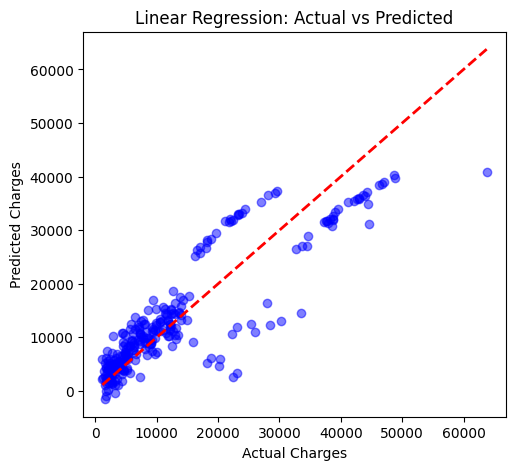

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Linear Regression: Actual vs Predicted')

The data points align closely with the red diagonal line at low and moderate cost levels, indicating good model performance in this segment. However, at very high cost levels, the model tends to underestimate actual values, and distinct clustering appears due to the influence of the smoking group.

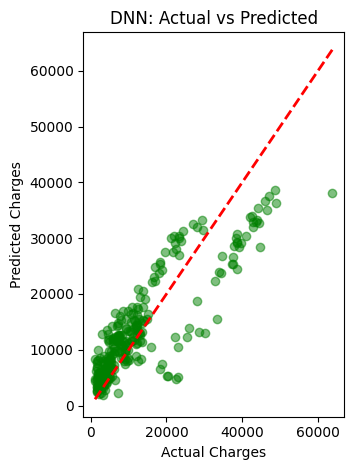

In [15]:
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_dnn, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('DNN: Actual vs Predicted')

plt.tight_layout()
plt.show()

The DNN model tends to show wider dispersion and less stability, with data points deviating further from the red diagonal line, reflecting why its overall performance is lower than that of Linear Regression.

# E. Conclusion. #

Key Takeaways:
- Data preprocessing (scaling, categorical encoding).
- Model building and training (Linear Regression and DNN).
- Performance evaluation using MSE and R^2.
- Visualizing and analyzing Actual vs. Predicted plots.
- Critical thinking in comparing simple versus complex models.